# **K-Means Clustering**

<img src="../images/sphx_glr_plot_cluster_comparison.png" width="900">

[Text(0.5, 1.0, 'Clustering Sample Dataset (Moons)'),
 Text(0.5, 0, 'feature_1'),
 Text(0, 0.5, 'feature_2')]

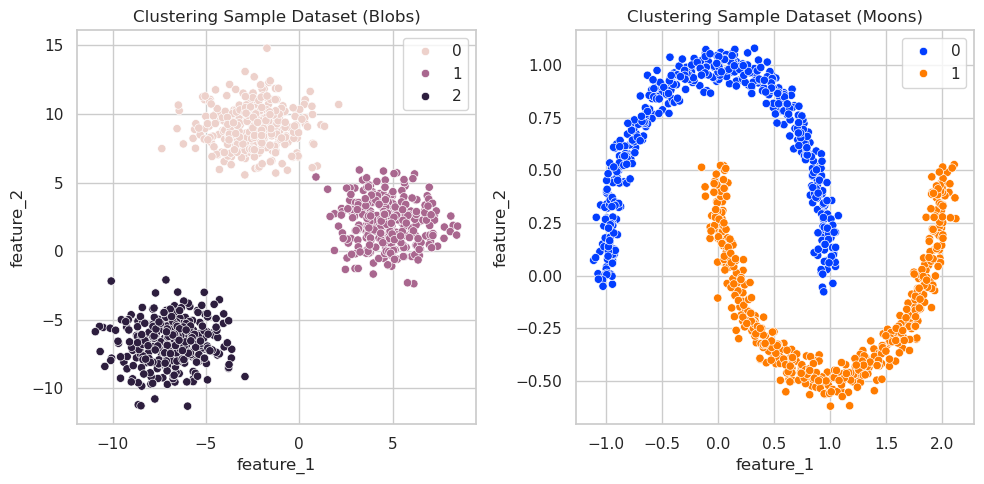

In [28]:
from sklearn.datasets import make_blobs, make_moons, make_swiss_roll
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="bright"
)

X1, labels1 = make_blobs(
    n_samples=1000, n_features=2 ,centers=3,
    cluster_std=1.5, random_state=42
)
X2, labels2 = make_moons(n_samples=1000, noise=0.05, random_state=42)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)
sns.scatterplot(x=X1[:, 0], y=X1[:, 1], hue=labels1, ax=axs[0])
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=labels2, ax=axs[1])

axs[0].set(
    title="Clustering Sample Dataset (Blobs)",
    xlabel="feature_1",
    ylabel="feature_2",
)
axs[1].set(
    title="Clustering Sample Dataset (Moons)",
    xlabel="feature_1",
    ylabel="feature_2",
)

### Key Steps:

1. Initialization
2. Assignment Step
3. Update Step
4. Convergence Check

>Note: This algorithm is sensitive to initialization, outliers, dimensionality, ...

The key pros of the k-means algorithm is it's flexibility and it's simplicity and interpretability.
> Note: Given enough time, **K-means will always converge**, however this may be to a local minimum.

In [27]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X1)
y_pred = kmeans.labels_

# K-means algorithm attributes
print(f"Centroids Coordinates: {kmeans.cluster_centers_}")
print(f"\nNumber of Iterations: {kmeans.n_iter_}")
print(f"\nNumber of Features in: {kmeans.n_features_in_}")
print(f"\nInertia (total within-cluster sum-of-squares): {kmeans.inertia_}")
print(f"\nClustering Labels:\n{kmeans.labels_}")

Centroids Coordinates: [[-2.5213978   8.98805719]
 [-6.86003021 -6.73773661]
 [ 4.78470523  2.08679581]]

Number of Iterations: 3

Number of Features in: 2

Inertia (total within-cluster sum-of-squares): 4387.8799788395745

Clustering Labels:
[1 1 2 0 0 1 2 2 2 2 0 1 0 2 2 2 0 0 0 0 2 1 1 1 2 0 0 0 2 2 1 1 2 0 0 1 1
 2 1 1 0 2 0 1 0 1 0 0 1 2 1 0 2 1 0 1 0 0 0 2 2 0 1 1 0 0 1 2 2 0 1 0 2 2
 2 1 2 0 0 0 2 0 0 0 2 1 2 1 0 0 0 0 2 2 1 2 1 0 2 2 2 1 1 0 1 2 2 0 2 0 1
 2 2 2 0 2 1 1 2 0 0 2 1 2 1 1 2 1 2 2 0 2 2 1 0 1 0 2 2 2 0 0 1 1 1 0 2 0
 0 0 0 1 2 1 0 2 0 2 0 1 2 0 0 2 0 0 2 2 1 1 2 0 0 2 0 1 2 1 2 1 0 2 0 2 0
 1 0 1 0 1 2 0 2 2 0 1 2 2 2 1 0 2 0 0 2 0 2 0 0 2 2 1 1 2 2 0 1 0 1 2 1 1
 2 0 1 0 0 2 1 0 0 1 0 1 2 2 1 2 1 2 1 1 1 2 1 0 2 0 2 0 2 2 1 2 0 2 0 2 2
 2 2 0 1 2 1 1 2 0 0 1 2 0 2 2 0 1 0 1 1 2 1 2 1 2 2 0 0 2 0 1 1 0 2 2 1 0
 2 1 1 0 1 1 2 1 0 2 1 2 1 1 1 1 1 2 1 1 2 0 1 1 2 1 1 2 1 2 0 2 0 0 2 2 1
 1 1 0 1 2 1 2 1 2 2 2 0 0 1 1 0 0 0 0 0 2 0 0 2 0 0 1 2 2 2 2 1 2 1 1 1 2
 2 0 0 

Text(0.5, 1.0, "Clustering Results on 'Blobs' Dataset")

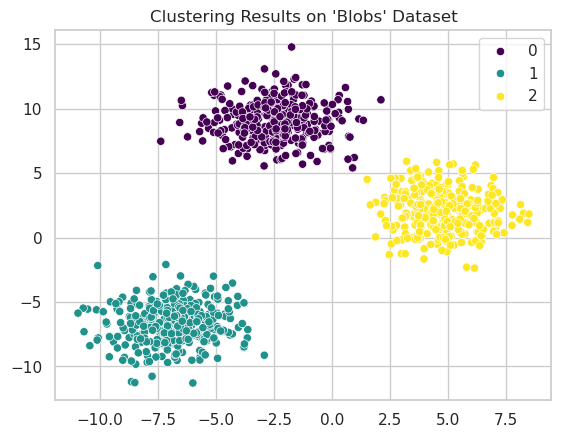

In [42]:
# visualization of the clustering
sns.scatterplot(x=X1[:, 0], y=X1[:, 1], hue=y_pred, palette="viridis")
plt.title("Clustering Results on 'Blobs' Dataset")

It's a best practice to standardized the data before running the k-means clustering algorithm cause:
- we put the data points in the same scale
- calculating distance works better in centered data

> Note: Be aware of the curse of dimensionality cause measuring methods like Euclidean distance becomes meaningless in high-dimensional data.

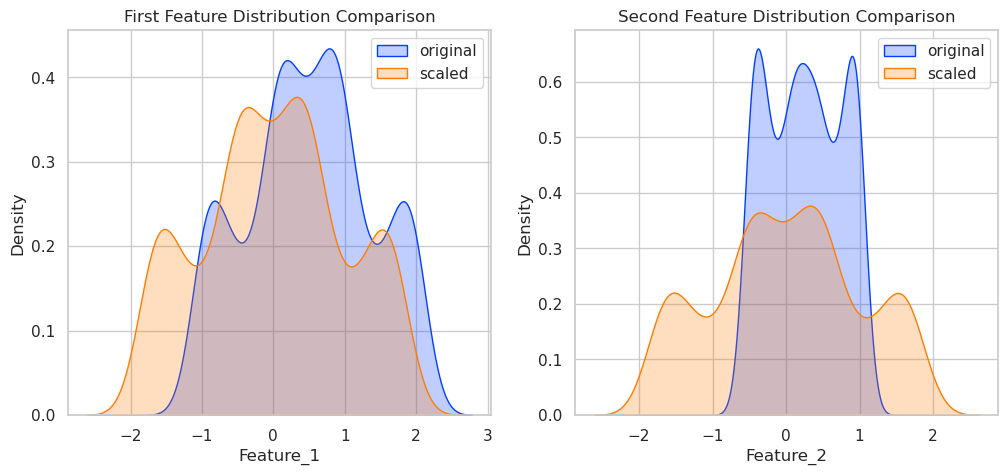

In [85]:
# cluster the moons dataset
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.kdeplot(x=X2[:, 0], fill=True, ax=axs[0], label="original")
sns.kdeplot(x=X2[:, 1], fill=True, ax=axs[1], label="original")
sns.kdeplot(x=X2_scaled[:, 0], fill=True, ax=axs[0], label="scaled")
sns.kdeplot(x=X2_scaled[:, 0], fill=True, ax=axs[1], label="scaled")

axs[0].set_title("First Feature Distribution Comparison")
axs[1].set_title("Second Feature Distribution Comparison")
axs[0].set_xlabel("Feature_1")
axs[1].set_xlabel("Feature_2")
for ax in axs:
    ax.legend()

In [125]:
scores = []
inertias = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X2_scaled)
    silhouette_score_ = silhouette_score(X2_scaled, kmeans.labels_)
    scores.append((k, silhouette_score_))
    inertias.append(kmeans.inertia_)

Scores:
 [[ 2.          0.49716227]
 [ 3.          0.4505251 ]
 [ 4.          0.44036221]
 [ 5.          0.47291371]
 [ 6.          0.49843259]
 [ 7.          0.50041538]
 [ 8.          0.50119354]
 [ 9.          0.50830796]
 [10.          0.51342459]
 [11.          0.51474378]
 [12.          0.51081048]
 [13.          0.5120837 ]
 [14.          0.50709236]]

Best Score: [[11.          0.51474378]]


Text(0.5, 0, 'K')

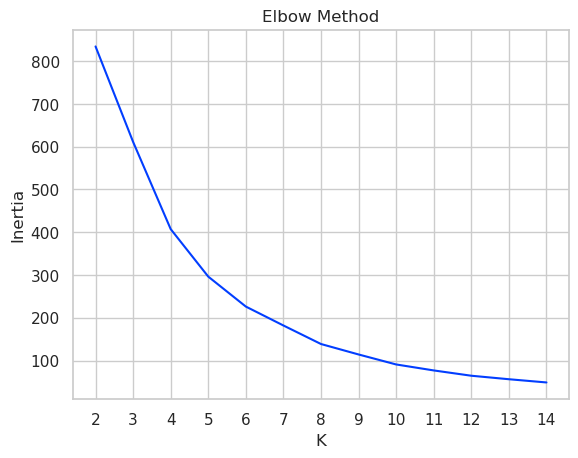

In [211]:
import numpy as np

# Silhouette Analysis
scores = np.array(scores)
maximum_score = scores[:, 1].max()
print("Scores:\n", scores)
print(f"\nBest Score: {scores[scores[:, 1] == maximum_score]}")

# Elbow Method
ax = sns.lineplot(x=scores[:, 0], y=inertias)
ax.set_xticks(range(2, 15))
ax.set_title("Elbow Method")
ax.set_ylabel("Inertia")
ax.set_xlabel("K")